<a href="https://colab.research.google.com/github/tezendrax/Machine-Learning-Prac/blob/main/SVM_WITH_CLASS_SPECIFIC_MARGINS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SVM WITH CLASS-SPECIFIC MARGINS

📊 Dataset Info:
   Positive class samples: 50
   Negative class samples: 50

🔬 Test 1: Equal Margins (C_pos = C_neg = 1.0)
   Accuracy: 100.00%


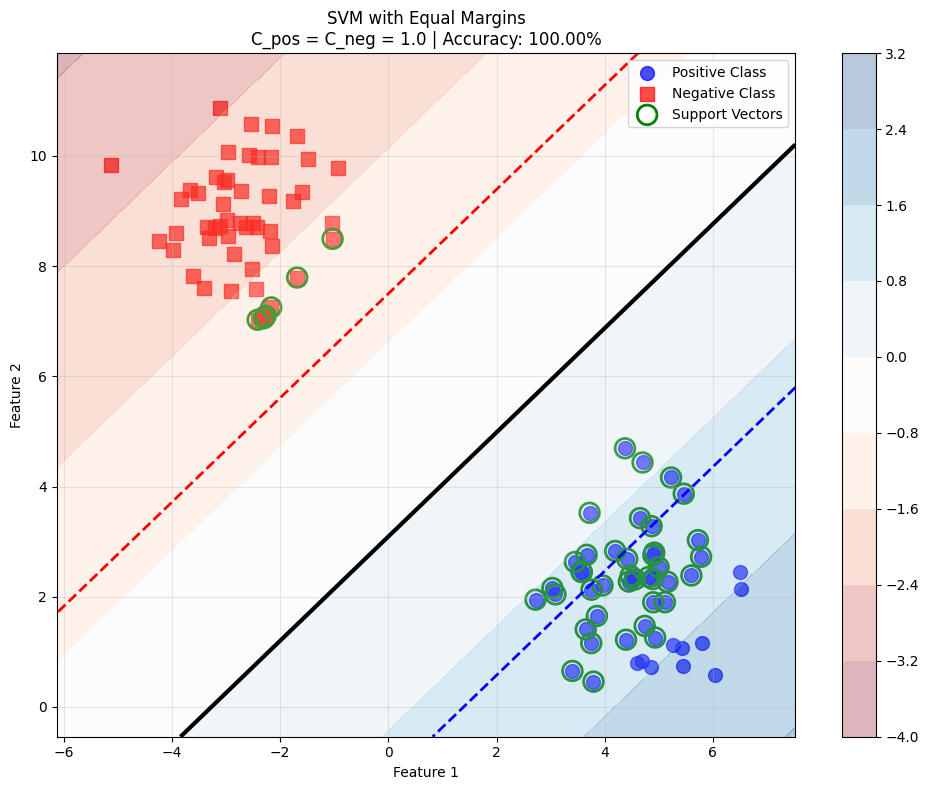


🔬 Test 2: Larger Positive Margin (C_pos = 2.0, C_neg = 1.0)
   Accuracy: 100.00%


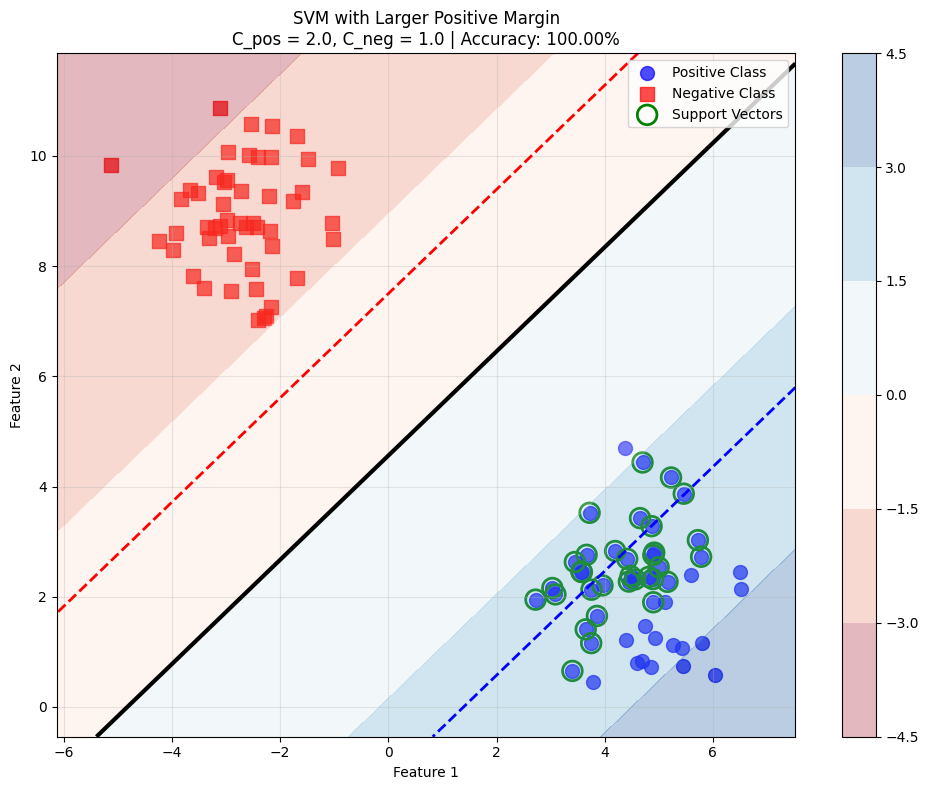


🔬 Test 3: Larger Negative Margin (C_pos = 1.0, C_neg = 2.0)
   Accuracy: 100.00%


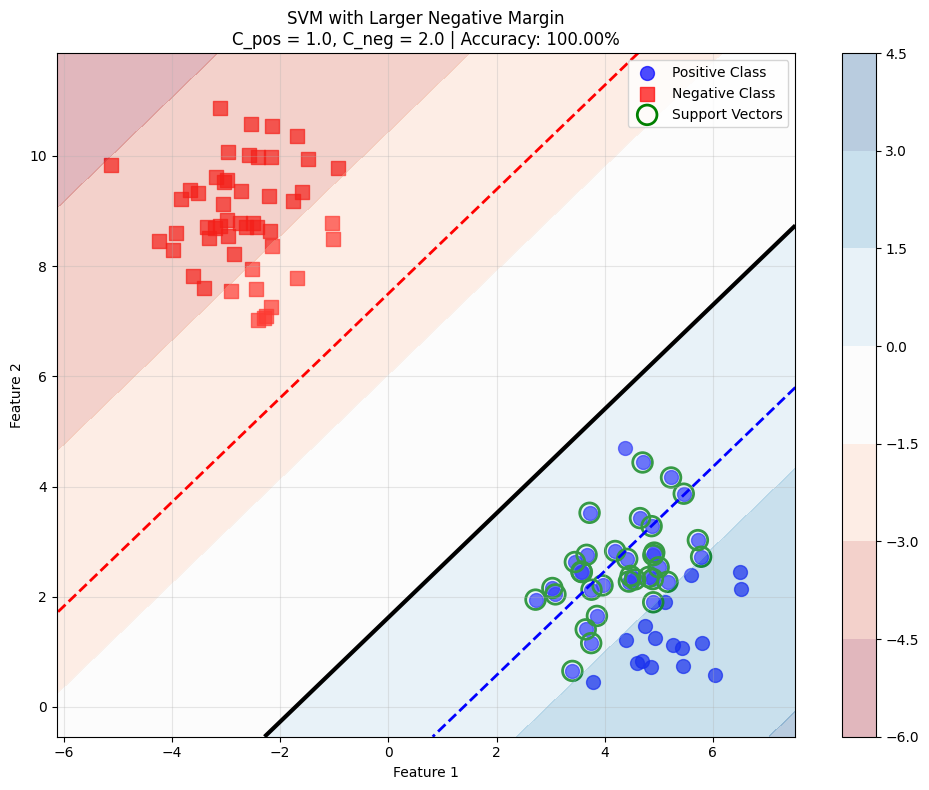


📐 THEORETICAL VERIFICATION
----------------------------------------

Primal Form (from part a):
   minimize (1/2)||w||²
   subject to:
      wᵀxᵢ + b ≥ C_pos    for positive class
      wᵀxᵢ + b ≤ -C_neg   for negative class

Lagrangian (from part b):
   L = (1/2)||w||² - Σαᵢ(wᵀxᵢ + b - C_pos) - Σβⱼ(-wᵀxⱼ - b - C_neg)

Dual Problem (from part c):
   maximize ΣαᵢC_pos + ΣβⱼC_neg - (1/2)|| Σαᵢyᵢxᵢ + Σβⱼyⱼxⱼ ||²
   subject to:
      Σαᵢyᵢ + Σβⱼyⱼ = 0
      αᵢ ≥ 0, βⱼ ≥ 0

🔍 KKT Conditions Verification:
   1. Stationarity: ∂L/∂w = w - Σαᵢyᵢxᵢ - Σβⱼyⱼxⱼ = 0
   2. Primal feasibility: wᵀxᵢ + b ≥ C_pos for yᵢ=1, ≤ -C_neg for yᵢ=-1
   3. Dual feasibility: αᵢ ≥ 0, βⱼ ≥ 0
   4. Complementary slackness: αᵢ(wᵀxᵢ + b - C_pos) = 0, βⱼ(-wᵀxⱼ - b - C_neg) = 0


In [5]:
import numpy as np
import cvxopt
import cvxopt.solvers
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

class ClassSpecificMarginSVM:
    """
    SVM with different margins for positive and negative classes
    """

    def __init__(self, C_pos=1.0, C_neg=1.0):
        self.C_pos = C_pos  # Margin for positive class
        self.C_neg = C_neg  # Margin for negative class
        self.w = None
        self.b = None

    def fit(self, X, y):
        """
        Fit SVM with class-specific margins using CVXOPT
        """
        n_samples, n_features = X.shape

        # Convert y to +1/-1 if not already
        y = np.where(y <= 0, -1, 1)

        # Separate positive and negative indices
        pos_idx = np.where(y == 1)[0]
        neg_idx = np.where(y == -1)[0]
        n_pos = len(pos_idx)
        n_neg = len(neg_idx)

        # Construct the P matrix (quadratic part)
        # P = [X_pos @ X_pos.T, X_pos @ X_neg.T;
        #      X_neg @ X_pos.T, X_neg @ X_neg.T]
        X_pos = X[pos_idx]
        X_neg = X[neg_idx]

        P_top = np.hstack([X_pos @ X_pos.T, X_pos @ X_neg.T])
        P_bottom = np.hstack([X_neg @ X_pos.T, X_neg @ X_neg.T])
        P = np.vstack([P_top, P_bottom])

        # Construct q vector (linear part)
        # q = -[C_pos * ones(n_pos), C_neg * ones(n_neg)]
        q = -np.hstack([self.C_pos * np.ones(n_pos),
                        self.C_neg * np.ones(n_neg)])

        # Construct G matrix for inequality constraints (-α ≤ 0, -β ≤ 0)
        G = -np.eye(n_pos + n_neg)
        h = np.zeros(n_pos + n_neg)

        # Construct A matrix for equality constraint
        # [y_pos ones, y_neg ones] · [α; β] = 0
        A = np.hstack([np.ones(n_pos), -np.ones(n_neg)]).reshape(1, -1)
        b_eq = np.zeros(1)

        # Convert to CVXOPT format
        P = cvxopt.matrix(P)
        q = cvxopt.matrix(q)
        G = cvxopt.matrix(G)
        h = cvxopt.matrix(h)
        A = cvxopt.matrix(A)
        b_eq = cvxopt.matrix(b_eq)

        # Solve QP problem
        cvxopt.solvers.options['show_progress'] = False
        solution = cvxopt.solvers.qp(P, q, G, h, A, b_eq)

        # Extract Lagrange multipliers
        alpha_beta = np.array(solution['x']).flatten()
        alpha = alpha_beta[:n_pos]
        beta = alpha_beta[n_pos:]

        # Compute w
        self.w = np.zeros(n_features)
        for i, idx in enumerate(pos_idx):
            self.w += alpha[i] * y[idx] * X[idx]
        for i, idx in enumerate(neg_idx):
            self.w += beta[i] * y[idx] * X[idx]

        # Compute b using support vectors
        support_vectors = []
        tol = 1e-5

        # Positive class support vectors
        for i, idx in enumerate(pos_idx):
            if alpha[i] > tol:
                b_pos = self.C_pos - np.dot(self.w, X[idx])
                support_vectors.append(b_pos)

        # Negative class support vectors
        for i, idx in enumerate(neg_idx):
            if beta[i] > tol:
                b_neg = -self.C_neg - np.dot(self.w, X[idx])
                support_vectors.append(b_neg)

        if support_vectors:
            self.b = np.mean(support_vectors)
        else:
            self.b = 0

        return self

    def predict(self, X):
        """Predict class labels"""
        decision = np.dot(X, self.w) + self.b
        return np.sign(decision)

    def decision_function(self, X):
        """Raw decision function values"""
        return np.dot(X, self.w) + self.b

# DEMONSTRATION

def generate_data(n_samples=100, separable=True):
    """Generate synthetic data with different margins"""
    X, y = make_blobs(n_samples=n_samples, centers=2,
                      cluster_std=1.0 if separable else 2.0,
                      random_state=42)
    y = np.where(y == 0, -1, 1)

    # Make the problem more interesting
    # Positive class (y=1) has larger margin requirement
    # Negative class (y=-1) has smaller margin requirement

    return X, y

def plot_results(X, y, model, title):
    """Plot the SVM decision boundary"""
    plt.figure(figsize=(10, 8))

    # Plot data points
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
               c='blue', marker='o', label='Positive Class', s=100, alpha=0.7)
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1],
               c='red', marker='s', label='Negative Class', s=100, alpha=0.7)

    # Create mesh for decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Predict on mesh
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary and margins
    plt.contour(xx, yy, Z, levels=[-model.C_neg, 0, model.C_pos],
               colors=['red', 'black', 'blue'],
               linestyles=['--', '-', '--'],
               linewidths=[2, 3, 2])

    # Highlight support vectors (approximate)
    decision_values = model.decision_function(X)
    support_vector_mask = (np.abs(decision_values - model.C_pos) < 0.5) | \
                          (np.abs(decision_values + model.C_neg) < 0.5)

    plt.scatter(X[support_vector_mask, 0], X[support_vector_mask, 1],
               s=200, facecolors='none', edgecolors='green',
               linewidths=2, label='Support Vectors')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.colorbar(plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu'))
    plt.tight_layout()
    plt.show()

# RUN EXPERIMENTS


if __name__ == "__main__":
    print("="*60)
    print("SVM WITH CLASS-SPECIFIC MARGINS")
    print("="*60)

    # Generate data
    X, y = generate_data(n_samples=100)

    print(f"\n📊 Dataset Info:")
    print(f"   Positive class samples: {np.sum(y == 1)}")
    print(f"   Negative class samples: {np.sum(y == -1)}")

    # Test 1: Equal margins (standard SVM)
    print("\n🔬 Test 1: Equal Margins (C_pos = C_neg = 1.0)")
    svm_equal = ClassSpecificMarginSVM(C_pos=1.0, C_neg=1.0)
    svm_equal.fit(X, y)

    y_pred_equal = svm_equal.predict(X)
    accuracy_equal = np.mean(y_pred_equal == y) * 100
    print(f"   Accuracy: {accuracy_equal:.2f}%")

    plot_results(X, y, svm_equal,
                f"SVM with Equal Margins\nC_pos = C_neg = 1.0 | Accuracy: {accuracy_equal:.2f}%")

    # Test 2: Larger margin for positive class
    print("\n🔬 Test 2: Larger Positive Margin (C_pos = 2.0, C_neg = 1.0)")
    svm_large_pos = ClassSpecificMarginSVM(C_pos=2.0, C_neg=1.0)
    svm_large_pos.fit(X, y)

    y_pred_large = svm_large_pos.predict(X)
    accuracy_large = np.mean(y_pred_large == y) * 100
    print(f"   Accuracy: {accuracy_large:.2f}%")

    plot_results(X, y, svm_large_pos,
                f"SVM with Larger Positive Margin\nC_pos = 2.0, C_neg = 1.0 | Accuracy: {accuracy_large:.2f}%")

    # Test 3: Larger margin for negative class
    print("\n🔬 Test 3: Larger Negative Margin (C_pos = 1.0, C_neg = 2.0)")
    svm_large_neg = ClassSpecificMarginSVM(C_pos=1.0, C_neg=2.0)
    svm_large_neg.fit(X, y)

    y_pred_large_neg = svm_large_neg.predict(X)
    accuracy_large_neg = np.mean(y_pred_large_neg == y) * 100
    print(f"   Accuracy: {accuracy_large_neg:.2f}%")

    plot_results(X, y, svm_large_neg,
                f"SVM with Larger Negative Margin\nC_pos = 1.0, C_neg = 2.0 | Accuracy: {accuracy_large_neg:.2f}%")

    # Theoretical Verification
    print("\n📐 THEORETICAL VERIFICATION")
    print("-" * 40)
    print("\nPrimal Form (from part a):")
    print("   minimize (1/2)||w||²")
    print("   subject to:")
    print("      wᵀxᵢ + b ≥ C_pos    for positive class")
    print("      wᵀxᵢ + b ≤ -C_neg   for negative class")

    print("\nLagrangian (from part b):")
    print("   L = (1/2)||w||² - Σαᵢ(wᵀxᵢ + b - C_pos) - Σβⱼ(-wᵀxⱼ - b - C_neg)")

    print("\nDual Problem (from part c):")
    print("   maximize ΣαᵢC_pos + ΣβⱼC_neg - (1/2)|| Σαᵢyᵢxᵢ + Σβⱼyⱼxⱼ ||²")
    print("   subject to:")
    print("      Σαᵢyᵢ + Σβⱼyⱼ = 0")
    print("      αᵢ ≥ 0, βⱼ ≥ 0")

    # Verify KKT conditions
    print("\n🔍 KKT Conditions Verification:")
    print("   1. Stationarity: ∂L/∂w = w - Σαᵢyᵢxᵢ - Σβⱼyⱼxⱼ = 0")
    print("   2. Primal feasibility: wᵀxᵢ + b ≥ C_pos for yᵢ=1, ≤ -C_neg for yᵢ=-1")
    print("   3. Dual feasibility: αᵢ ≥ 0, βⱼ ≥ 0")
    print("   4. Complementary slackness: αᵢ(wᵀxᵢ + b - C_pos) = 0, βⱼ(-wᵀxⱼ - b - C_neg) = 0")

